# Proyecto ML — EDA y Baseline (Entrega 1)

**Problema:** clasificación multiclase del macro-género musical a partir de features de audio de Spotify.

**Variable objetivo:** `macro_genre` (derivada de `track_genre` por agrupamiento manual).

**Métrica primaria:** macro-F1. Secundarias: accuracy, top-3 accuracy, matriz de confusión.

**Dataset:** [maharshipandya/-spotify-tracks-dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) — 114 000 tracks, 125 sub-géneros.

---

**Secciones:**
0. Setup
1. Carga e inspección
2. Definición del problema y mapeo de géneros
3. Análisis exploratorio (EDA)
4. Calidad de datos y limpieza
5. Train/test split + pipeline de preprocesamiento
6. Baseline ingenuo (`DummyClassifier`)
7. Baseline real (`LogisticRegression`)
8. Comparación y conclusiones

## 0. Setup

In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    top_k_accuracy_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import (
    plot_correlation_heatmap,
    plot_target_distribution,
    quick_overview,
    save_fig,
)

RANDOM_STATE = 42
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "spotify_tracks.csv"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH:    {DATA_PATH}")
print(f"Existe CSV?:  {DATA_PATH.exists()}")

PROJECT_ROOT: /Users/danielavillamizar/Documents/GitHub/Proyecto_ML_Spotify
DATA_PATH:    /Users/danielavillamizar/Documents/GitHub/Proyecto_ML_Spotify/data/raw/spotify_tracks.csv
Existe CSV?:  True


## 1. Carga e inspección

In [5]:
df = pd.read_csv(DATA_PATH)
# Algunas versiones del CSV traen una columna índice `Unnamed: 0`. La quitamos si aparece.
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")
quick_overview(df)

Shape: (114000, 20)
Duplicados exactos: 450

Dtypes:
float64    9
str        5
int64      5
bool       1
Name: count, dtype: int64

Missing por columna:
artists       1
album_name    1
track_name    1
dtype: int64

Primeras filas:
                 track_id                 artists  \
0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73    

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985
energy,114000.0,NaN,NaN,NaN,0.641383,0.251529,0.0,0.472,0.685,0.854,1.0
key,114000.0,NaN,NaN,NaN,5.30914,3.559987,0.0,2.0,5.0,8.0,11.0


## 2. Definición del problema y mapeo de géneros

El dataset trae 125 sub-géneros. Muchos son ambiguos o sub-variantes (`pop` vs `power-pop` vs `indie-pop`).
Agrupamos a ~10 **macro-géneros** para:

- Hacer la clasificación tratable (menos clases, más ejemplos por clase).
- Facilitar interpretación de la matriz de confusión.
- Reducir el ruido de etiquetas ambiguas.

**TODO equipo:** completar `GENRE_MAPPING` asignando cada sub-género a una macro-categoría. Cualquier sub-género sin asignar caerá en `"other"`.

In [7]:
sub_genres = sorted(df["track_genre"].unique().tolist())
print(f"Sub-géneros únicos: {len(sub_genres)}")
sub_genres

Sub-géneros únicos: 114


['acoustic',
 'afrobeat',
 'alt-rock',
 'alternative',
 'ambient',
 'anime',
 'black-metal',
 'bluegrass',
 'blues',
 'brazil',
 'breakbeat',
 'british',
 'cantopop',
 'chicago-house',
 'children',
 'chill',
 'classical',
 'club',
 'comedy',
 'country',
 'dance',
 'dancehall',
 'death-metal',
 'deep-house',
 'detroit-techno',
 'disco',
 'disney',
 'drum-and-bass',
 'dub',
 'dubstep',
 'edm',
 'electro',
 'electronic',
 'emo',
 'folk',
 'forro',
 'french',
 'funk',
 'garage',
 'german',
 'gospel',
 'goth',
 'grindcore',
 'groove',
 'grunge',
 'guitar',
 'happy',
 'hard-rock',
 'hardcore',
 'hardstyle',
 'heavy-metal',
 'hip-hop',
 'honky-tonk',
 'house',
 'idm',
 'indian',
 'indie',
 'indie-pop',
 'industrial',
 'iranian',
 'j-dance',
 'j-idol',
 'j-pop',
 'j-rock',
 'jazz',
 'k-pop',
 'kids',
 'latin',
 'latino',
 'malay',
 'mandopop',
 'metal',
 'metalcore',
 'minimal-techno',
 'mpb',
 'new-age',
 'opera',
 'pagode',
 'party',
 'piano',
 'pop',
 'pop-film',
 'power-pop',
 'progressive

In [8]:
GENRE_MAPPING: dict[str, str] = {
    # ── rock ──────────────────────────────────────────────────────────────
    "rock":             "rock",
    "alt-rock":         "rock",
    "alternative":      "rock",
    "hard-rock":        "rock",
    "punk":             "rock",
    "punk-rock":        "rock",
    "grunge":           "rock",
    "indie":            "rock",
    "rock-n-roll":      "rock",
    "rockabilly":       "rock",
    "psych-rock":       "rock",
    "emo":              "rock",
    "goth":             "rock",
    "british":          "rock",   # British Invasion / classic British rock-pop
    # ── metal ─────────────────────────────────────────────────────────────
    "metal":            "metal",
    "black-metal":      "metal",
    "death-metal":      "metal",
    "heavy-metal":      "metal",
    "metalcore":        "metal",
    "grindcore":        "metal",
    "hardcore":         "metal",
    "industrial":       "metal",
    # ── pop ───────────────────────────────────────────────────────────────
    "pop":              "pop",
    "power-pop":        "pop",
    "indie-pop":        "pop",
    "synth-pop":        "pop",
    "pop-film":         "pop",
    "swedish":          "pop",    # Swedish pop tradition
    "party":            "pop",
    "happy":            "pop",
    "romance":          "pop",
    "sad":              "pop",
    # ── electronic ────────────────────────────────────────────────────────
    "electronic":       "electronic",
    "edm":              "electronic",
    "house":            "electronic",
    "deep-house":       "electronic",
    "chicago-house":    "electronic",
    "progressive-house":"electronic",
    "techno":           "electronic",
    "detroit-techno":   "electronic",
    "minimal-techno":   "electronic",
    "trance":           "electronic",
    "dubstep":          "electronic",
    "drum-and-bass":    "electronic",
    "breakbeat":        "electronic",
    "hardstyle":        "electronic",
    "idm":              "electronic",
    "electro":          "electronic",
    "disco":            "electronic",
    "dance":            "electronic",
    "club":             "electronic",
    "garage":           "electronic",  # UK garage
    # ── hip-hop / r&b ─────────────────────────────────────────────────────
    "hip-hop":          "hip-hop",
    "r-n-b":            "hip-hop",
    "trip-hop":         "hip-hop",
    # ── latin ─────────────────────────────────────────────────────────────
    "latin":            "latin",
    "latino":           "latin",
    "reggaeton":        "latin",
    "salsa":            "latin",
    "samba":            "latin",
    "tango":            "latin",
    "brazil":           "latin",
    "pagode":           "latin",
    "forro":            "latin",
    "mpb":              "latin",
    "sertanejo":        "latin",
    "spanish":          "latin",
    # ── jazz ──────────────────────────────────────────────────────────────
    "jazz":             "jazz",
    # ── classical ─────────────────────────────────────────────────────────
    "classical":        "classical",
    "opera":            "classical",
    "piano":            "classical",
    # ── folk / country ────────────────────────────────────────────────────
    "folk":             "folk",
    "country":          "folk",
    "bluegrass":        "folk",
    "honky-tonk":       "folk",
    "acoustic":         "folk",
    "singer-songwriter":"folk",
    "songwriter":       "folk",
    "guitar":           "folk",
    # ── reggae ────────────────────────────────────────────────────────────
    "reggae":           "reggae",
    "dub":              "reggae",
    "ska":              "reggae",
    "dancehall":        "reggae",
    # ── soul / funk / blues ───────────────────────────────────────────────
    "soul":             "soul-funk",
    "funk":             "soul-funk",
    "blues":            "soul-funk",
    "groove":           "soul-funk",
    "gospel":           "soul-funk",
    # ── world music ───────────────────────────────────────────────────────
    "world-music":      "world",
    "afrobeat":         "world",
    "indian":           "world",
    "turkish":          "world",
    "iranian":          "world",
    "malay":            "world",
    "french":           "world",
    "german":           "world",
    # ── kids / comedy ─────────────────────────────────────────────────────
    "children":         "kids-comedy",
    "kids":             "kids-comedy",
    "disney":           "kids-comedy",
    "comedy":           "kids-comedy",
    "show-tunes":       "kids-comedy",
    "anime":            "kids-comedy",
    # ── asian pop ─────────────────────────────────────────────────────────
    "j-pop":            "asian-pop",
    "k-pop":            "asian-pop",
    "j-rock":           "asian-pop",
    "j-dance":          "asian-pop",
    "j-idol":           "asian-pop",
    "cantopop":         "asian-pop",
    "mandopop":         "asian-pop",
    # ── ambient / instrumental ────────────────────────────────────────────
    "ambient":          "ambient",
    "new-age":          "ambient",
    "chill":            "ambient",
    "sleep":            "ambient",
    "study":            "ambient",
}

df["macro_genre"] = df["track_genre"].map(GENRE_MAPPING).fillna("other")

# Sanity check: show unmapped sub-genres
unmapped = sorted(set(df["track_genre"].unique()) - set(GENRE_MAPPING.keys()))
print(f"Sub-géneros sin mapear (→ 'other'): {unmapped}")
print()
print(df["macro_genre"].value_counts())

Sub-géneros sin mapear (→ 'other'): []

macro_genre
electronic     20000
rock           14000
latin          12000
pop            10000
folk            8000
world           8000
metal           8000
asian-pop       7000
kids-comedy     6000
ambient         5000
soul-funk       5000
reggae          4000
classical       3000
hip-hop         3000
jazz            1000
Name: count, dtype: int64


## 3. Análisis exploratorio (EDA)

### 3.1 Distribución del target

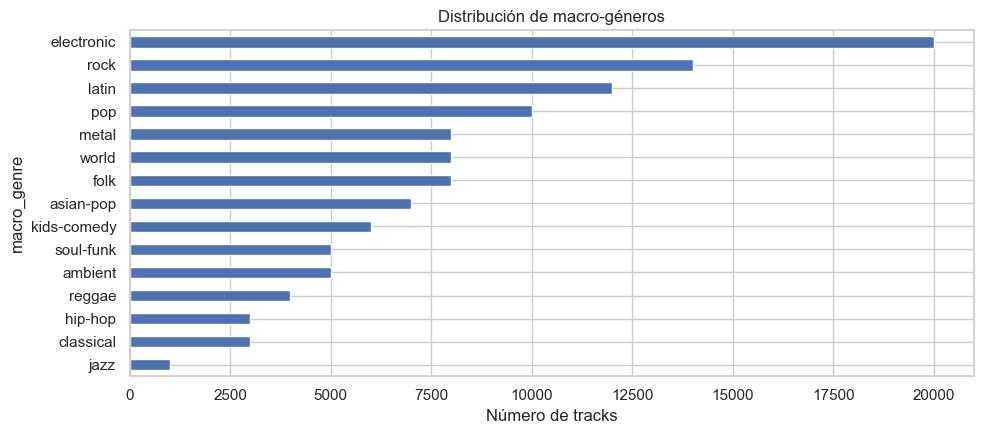

In [9]:
fig, ax = plot_target_distribution(
    df["macro_genre"], title="Distribución de macro-géneros"
)
save_fig("target_distribution")
plt.show()

### 3.2 Features numéricas

In [10]:
NUMERIC_FEATURES = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
]
CATEGORICAL_FEATURES = ["key", "mode", "time_signature", "explicit"]

df[NUMERIC_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996
instrumentalness,114000.0,0.156050,0.309555,0.000,0.00000,0.000042,0.0490,1.000
liveness,114000.0,0.213553,0.190378,0.000,0.09800,0.132000,0.2730,1.000
valence,114000.0,0.474068,0.259261,0.000,0.26000,0.464000,0.6830,0.995
tempo,114000.0,122.147837,29.978197,0.000,99.21875,122.017000,140.0710,243.372
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000


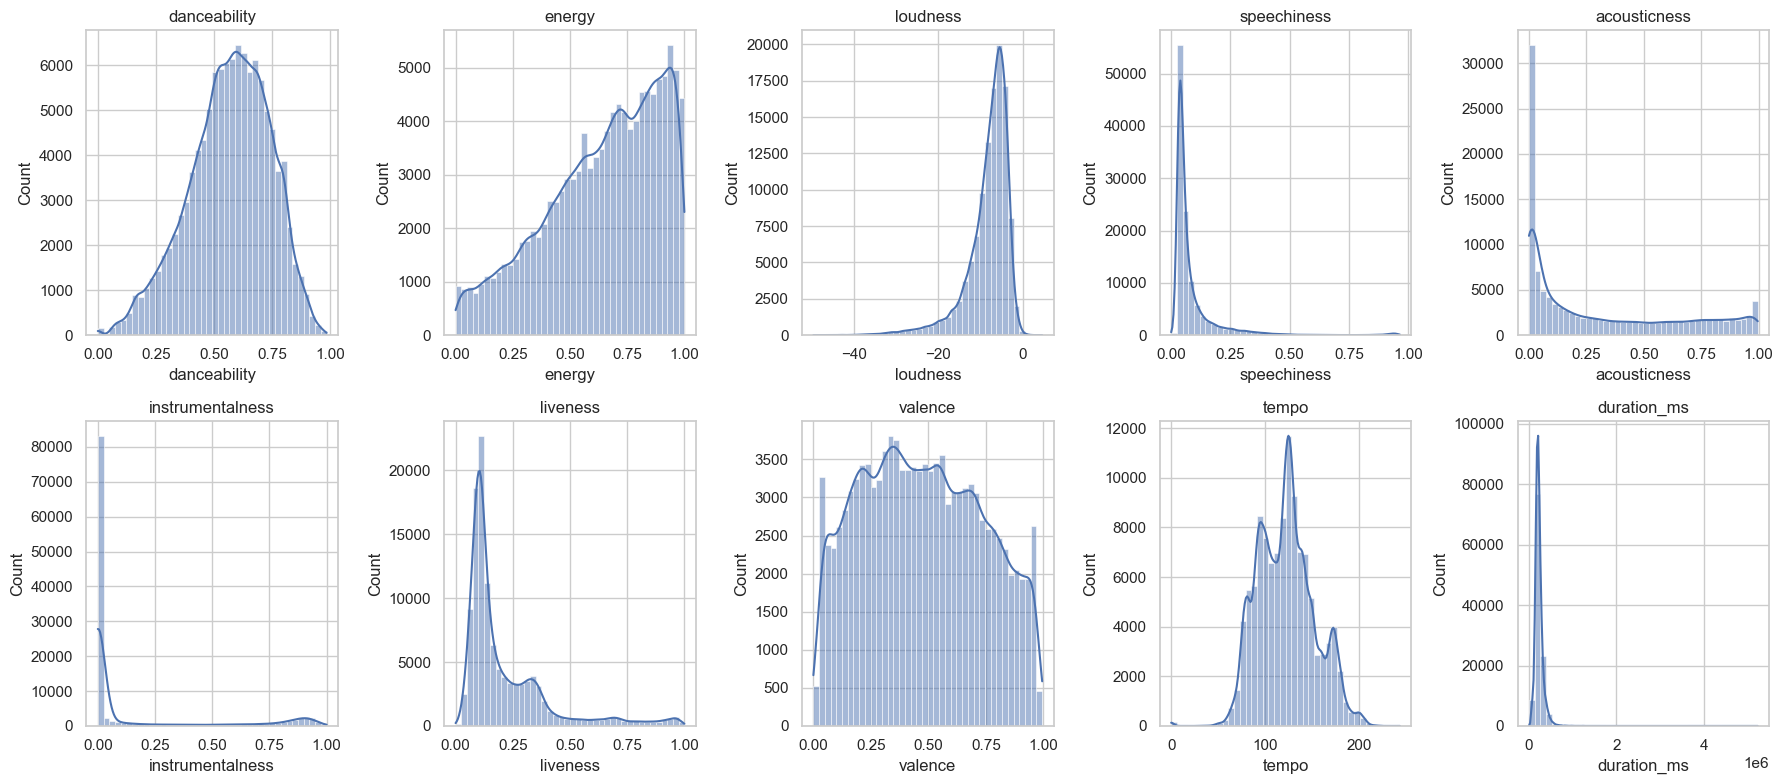

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, col in zip(axes.flatten(), NUMERIC_FEATURES):
    sns.histplot(df[col], bins=40, ax=ax, kde=True)
    ax.set_title(col)
save_fig("numerical_distributions")
plt.show()

### 3.3 Correlaciones

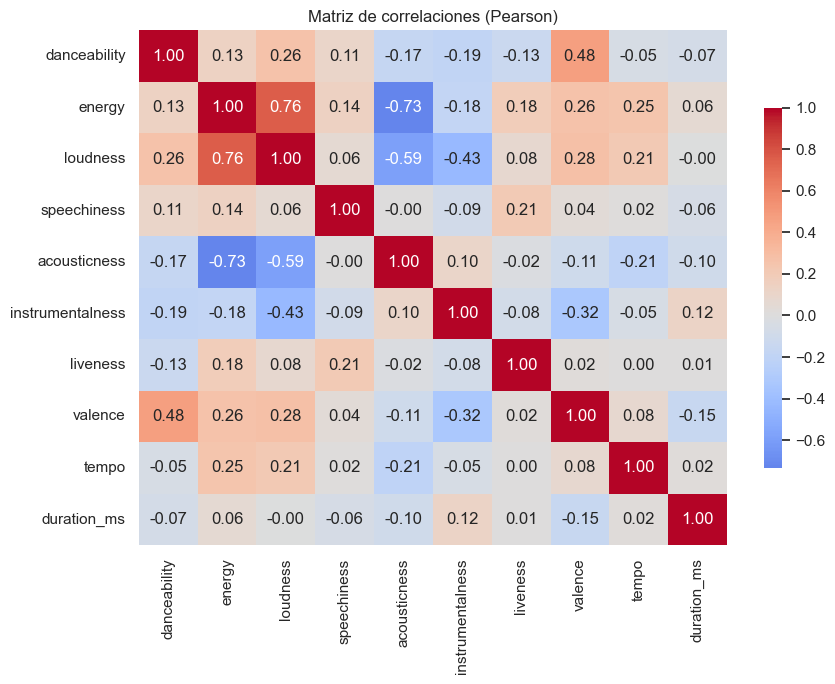

In [12]:
fig, ax = plot_correlation_heatmap(df, NUMERIC_FEATURES)
save_fig("correlation_heatmap")
plt.show()

### 3.4 Relación features → target

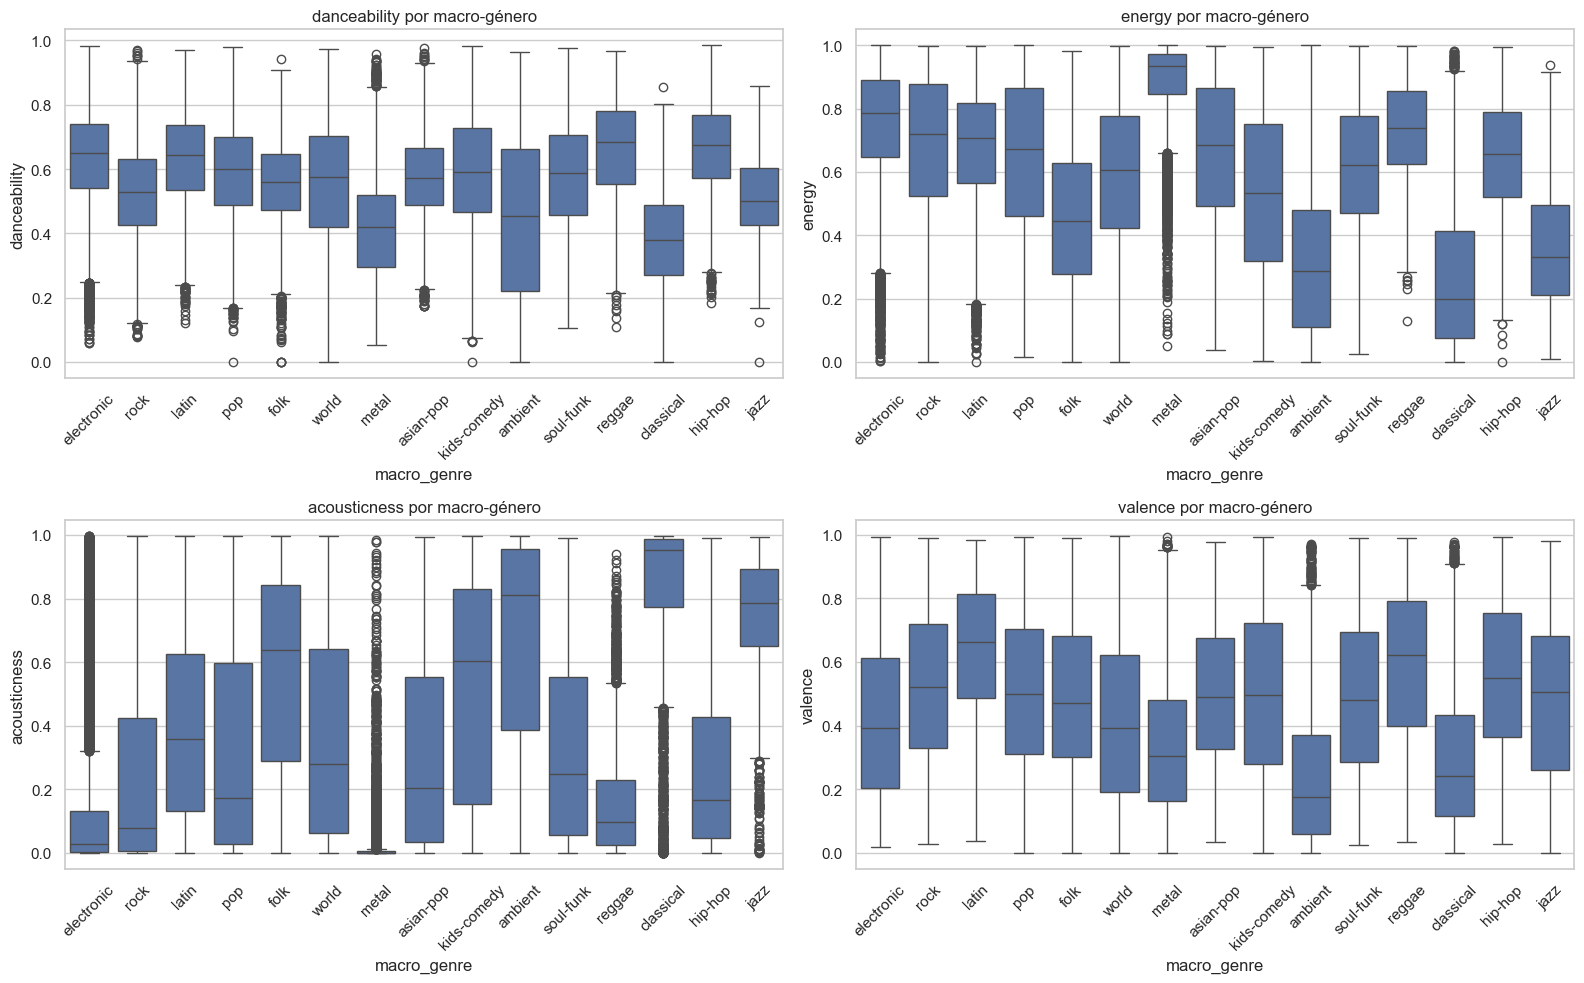

In [13]:
# Boxplots de 4 features clave por macro-género
features_to_plot = ["danceability", "energy", "acousticness", "valence"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
order = df["macro_genre"].value_counts().index.tolist()
for ax, col in zip(axes.flatten(), features_to_plot):
    sns.boxplot(data=df, x="macro_genre", y=col, order=order, ax=ax)
    ax.set_title(f"{col} por macro-género")
    ax.tick_params(axis="x", rotation=45)
save_fig("features_by_genre")
plt.show()

## 4. Calidad de datos y limpieza

In [14]:
# 4.1 Duplicados por track_id (el autor advierte que la misma canción puede estar varias veces).
print(f"Filas antes de deduplicar: {len(df):,}")
print(f"Duplicados por track_id:   {df.duplicated('track_id').sum():,}")
df = df.drop_duplicates(subset="track_id").reset_index(drop=True)
print(f"Filas después:             {len(df):,}")

Filas antes de deduplicar: 114,000
Duplicados por track_id:   24,259
Filas después:             89,741


In [15]:
# 4.2 Missing values
na = df.isna().sum()
print(na[na > 0] if (na > 0).any() else "Sin valores faltantes.")

artists       1
album_name    1
track_name    1
dtype: int64


In [16]:
# 4.3 Outliers básicos: tracks con duración absurdamente corta o tempo cero.
mask_bad = (df["duration_ms"] < 30_000) | (df["tempo"] == 0)
print(f"Tracks con duración < 30 s o tempo = 0: {mask_bad.sum():,}")
df = df.loc[~mask_bad].reset_index(drop=True)
print(f"Filas tras filtrar outliers básicos: {len(df):,}")

Tracks con duración < 30 s o tempo = 0: 170
Filas tras filtrar outliers básicos: 89,571


## 5. Train/test split + pipeline de preprocesamiento

- Split **estratificado** por `macro_genre`, 80/20, `random_state=42`.
- Preprocesamiento dentro de `Pipeline` para evitar **leakage**: `StandardScaler` para numéricas, `OneHotEncoder` para categóricas.

In [17]:
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "macro_genre"

X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Clases: {sorted(y.unique())}")

Train: (71656, 14), Test: (17915, 14)
Clases: ['ambient', 'asian-pop', 'classical', 'electronic', 'folk', 'hip-hop', 'jazz', 'kids-comedy', 'latin', 'metal', 'pop', 'reggae', 'rock', 'soul-funk', 'world']


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            CATEGORICAL_FEATURES,
        ),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 6. Baseline ingenuo — `DummyClassifier`

In [21]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)

dummy_results = {
    "accuracy": accuracy_score(y_test, y_pred_dummy),
    "macro_f1": f1_score(y_test, y_pred_dummy, average="macro"),
    "top3_acc": top_k_accuracy_score(y_test, y_proba_dummy, k=3, labels=dummy.classes_),
}
dummy_results

{'accuracy': 0.08724532514652526,
 'macro_f1': 0.06423170060849574,
 'top3_acc': 0.20932179737650014}

## 7. Baseline real — `LogisticRegression` multinomial

In [22]:
logreg_pipe = Pipeline(
    steps=[
        ("pre", preprocessor),
        (
            "clf",
            LogisticRegression(
                max_iter=2000,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
logreg_pipe.fit(X_train, y_train)
y_pred_lr = logreg_pipe.predict(X_test)
y_proba_lr = logreg_pipe.predict_proba(X_test)

logreg_results = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "macro_f1": f1_score(y_test, y_pred_lr, average="macro"),
    "top3_acc": top_k_accuracy_score(
        y_test, y_proba_lr, k=3, labels=logreg_pipe.classes_
    ),
}
logreg_results

/Users/danielavillamizar/Documents/GitHub/Proyecto_ML_Spotify/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'accuracy': 0.34959531119173876,
 'macro_f1': 0.2344952401700314,
 'top3_acc': 0.6160759140385152}

In [23]:
print(classification_report(y_test, y_pred_lr, digits=3))

              precision    recall  f1-score   support

     ambient      0.413     0.469     0.439       960
   asian-pop      0.197     0.065     0.098      1147
   classical      0.309     0.185     0.232       502
  electronic      0.405     0.743     0.524      3180
        folk      0.264     0.381     0.312      1235
     hip-hop      0.235     0.009     0.017       447
        jazz      0.323     0.096     0.148       104
 kids-comedy      0.386     0.265     0.315      1168
       latin      0.331     0.524     0.405      1835
       metal      0.512     0.620     0.561      1286
         pop      0.166     0.023     0.040      1522
      reggae      0.163     0.026     0.045       575
        rock      0.234     0.320     0.270      1840
   soul-funk      0.263     0.007     0.014       692
       world      0.227     0.061     0.096      1422

    accuracy                          0.350     17915
   macro avg      0.295     0.253     0.234     17915
weighted avg      0.309   

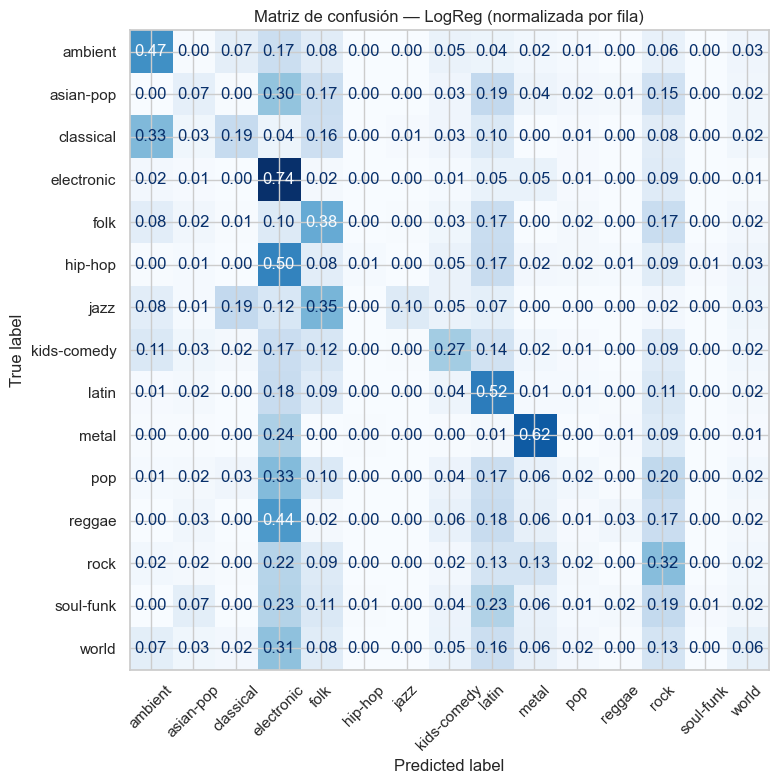

In [24]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_lr, labels=labels, normalize="true")
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=ax, xticks_rotation=45, values_format=".2f", cmap="Blues", colorbar=False
)
ax.set_title("Matriz de confusión — LogReg (normalizada por fila)")
save_fig("confusion_matrix_logreg")
plt.show()

## 8. Comparación y conclusiones

In [25]:
results = pd.DataFrame({"dummy": dummy_results, "logreg": logreg_results}).T
results

,accuracy,macro_f1,top3_acc
dummy,0.087245,0.064232,0.209322
logreg,0.349595,0.234495,0.616076


**Observaciones clave (TODO equipo — redactar en el reporte):**

- Mejora absoluta y relativa de LogReg sobre Dummy en cada métrica.
- Clases con mejor y peor F1 — asociarlas con hipótesis del EDA (por ej., "metal" y "classical" suelen ser fáciles; "pop" vs "rock" suelen confundirse).
- Pares de clases más confundidos en la matriz de confusión.
- Limitaciones del modelo lineal — justifica probar árboles y boosting en la Entrega 2.